# Task 4: HNSW Vector Index from Scratch

## Objective

Implement a simplified Hierarchical Navigable Small World (HNSW) vector index from scratch using NumPy.

The implementation demonstrates:

- Vector generation
- Distance calculation
- Hierarchical graph construction
- Neighbor selection
- Greedy search
- Approximate nearest-neighbor search
- Comparison with exact nearest-neighbor search
- Search recall
- Search-time analysis

## Tech Stack

- Python
- NumPy
- Matplotlib
- Pandas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Generate a Vector Dataset

We create a collection of high-dimensional vectors.

Each vector represents an item in a vector database.

In [2]:
num_vectors = 1000
vector_dimension = 32

vectors = np.random.randn(
    num_vectors,
    vector_dimension
).astype(np.float32)

vectors /= (
    np.linalg.norm(vectors, axis=1, keepdims=True)
    + 1e-10
)

print("Number of vectors:", num_vectors)
print("Vector dimension:", vector_dimension)
print("Dataset shape:", vectors.shape)

Number of vectors: 1000
Vector dimension: 32
Dataset shape: (1000, 32)


## Step 2: Define Distance Function

HNSW commonly uses a distance or similarity measure to determine which vectors are close to one another.

We use Euclidean distance for this implementation.

In [3]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)


def distances_to_query(query, data):
    return np.linalg.norm(
        data - query,
        axis=1
    )


query = vectors[0]

sample_distances = distances_to_query(
    query,
    vectors[:10]
)

print("Distances from query to first 10 vectors:")
print(sample_distances)

Distances from query to first 10 vectors:
[0.        1.5519018 1.3218691 1.4726287 1.3231974 1.4178972 1.509115
 1.5727574 1.5677605 1.6150897]


## Step 3: Define the HNSW Graph

HNSW consists of multiple hierarchical layers.

Higher layers contain fewer nodes and allow long-range navigation.

The bottom layer contains the complete graph.

In [4]:
class HNSWIndex:

    def __init__(
        self,
        max_neighbors=8,
        max_layers=4
    ):

        self.max_neighbors = max_neighbors
        self.max_layers = max_layers

        self.layers = [
            {}
            for _ in range(max_layers)
        ]

        self.node_levels = {}

        self.entry_point = None

    def random_level(self):

        level = 0

        while (
            level < self.max_layers - 1
            and np.random.rand() < 0.5
        ):
            level += 1

        return level

## Step 4: Select Neighbors

When inserting a vector, nearby vectors are selected as neighbors.

This creates the navigable small-world graph.

In [ ]:
def select_neighbors(
        self,
        node,
        candidates,
        data
    ):

        if not candidates:
            return []

        distances = [
            (
                candidate,
                euclidean_distance(
                    data[node],
                    data[candidate]
                )
            )
            for candidate in candidates
        ]

        distances.sort(
            key=lambda x: x[1]
        )

        return [
            candidate
            for candidate, _ in distances[
                :self.max_neighbors
            ]
        ]

## Step 5: Insert Vectors into the HNSW Index

In [6]:
def insert(self, node, data):

        level = self.random_level()

        self.node_levels[node] = level

        if self.entry_point is None:

            self.entry_point = node

            for layer in range(level + 1):
                self.layers[layer][node] = []

            return

        for layer in range(level + 1):

            existing_nodes = list(
                self.layers[layer].keys()
            )

            neighbors = self.select_neighbors(
                node,
                existing_nodes,
                data
            )

            self.layers[layer][node] = neighbors

            for neighbor in neighbors:

                self.layers[layer].setdefault(
                    neighbor,
                    []
                )

                self.layers[layer][neighbor].append(
                    node
                )

                self.layers[layer][neighbor] = (
                    self.layers[layer][neighbor]
                    [:self.max_neighbors]
                )

## Step 6: Build the HNSW Index

In [8]:
class HNSWIndex:

    def __init__(self, max_neighbors=8, max_layers=4):

        self.max_neighbors = max_neighbors
        self.max_layers = max_layers

        self.layers = [
            {}
            for _ in range(max_layers)
        ]

        self.node_levels = {}
        self.entry_point = None

    def random_level(self):

        level = 0

        while (
            level < self.max_layers - 1
            and np.random.rand() < 0.5
        ):
            level += 1

        return level

    def select_neighbors(
        self,
        node,
        candidates,
        data
    ):

        if not candidates:
            return []

        distances = [
            (
                candidate,
                euclidean_distance(
                    data[node],
                    data[candidate]
                )
            )
            for candidate in candidates
        ]

        distances.sort(
            key=lambda x: x[1]
        )

        return [
            candidate
            for candidate, _ in distances[
                :self.max_neighbors
            ]
        ]

    def insert(self, node, data):

        level = self.random_level()

        self.node_levels[node] = level

        if self.entry_point is None:

            self.entry_point = node

            for layer in range(level + 1):
                self.layers[layer][node] = []

            return

        for layer in range(level + 1):

            existing_nodes = list(
                self.layers[layer].keys()
            )

            neighbors = self.select_neighbors(
                node,
                existing_nodes,
                data
            )

            self.layers[layer][node] = neighbors

            for neighbor in neighbors:

                self.layers[layer].setdefault(
                    neighbor,
                    []
                )

                self.layers[layer][neighbor].append(
                    node
                )

                # Keep only the closest neighbors
                self.layers[layer][neighbor] = sorted(
                    self.layers[layer][neighbor],
                    key=lambda x: euclidean_distance(
                        data[neighbor],
                        data[x]
                    )
                )[:self.max_neighbors]

## Step 7: Inspect the Hierarchical Graph

HNSW contains multiple layers.

Higher layers contain fewer nodes and provide long-range navigation, while the bottom layer contains the main graph used for detailed searching.

In [9]:
for layer_number, layer in enumerate(hnsw.layers):

    print(
        f"Layer {layer_number}: "
        f"{len(layer)} nodes"
    )

Layer 0: 0 nodes
Layer 1: 0 nodes
Layer 2: 0 nodes
Layer 3: 0 nodes


## Step 8: Implement Greedy Search

Greedy search starts from an entry point and repeatedly moves to a neighboring vector that is closer to the query.

This allows the search to navigate through the graph without comparing the query with every vector.

In [10]:
def greedy_search(
    query,
    entry_point,
    layer,
    data
):

    current = entry_point

    current_distance = euclidean_distance(
        query,
        data[current]
    )

    improved = True

    while improved:

        improved = False

        neighbors = layer.get(
            current,
            []
        )

        for neighbor in neighbors:

            distance = euclidean_distance(
                query,
                data[neighbor]
            )

            if distance < current_distance:

                current = neighbor
                current_distance = distance

                improved = True

    return current

## Step 9: Implement HNSW Approximate Search

The search starts from the highest available layer and moves downward toward the bottom layer.

The bottom layer is then explored to find the nearest candidate vectors.

In [11]:
def search_hnsw(
    query,
    data,
    index,
    top_k=5
):

    current = index.entry_point

    # Search from the highest layer
    for layer_number in range(
        len(index.layers) - 1,
        0,
        -1
    ):

        if current in index.layers[layer_number]:

            current = greedy_search(
                query,
                current,
                index.layers[layer_number],
                data
            )

    # Search the bottom layer
    bottom_layer = index.layers[0]

    visited = set()
    candidates = [current]
    results = []

    while candidates:

        node = candidates.pop()

        if node in visited:
            continue

        visited.add(node)

        distance = euclidean_distance(
            query,
            data[node]
        )

        results.append(
            (node, distance)
        )

        for neighbor in bottom_layer.get(
            node,
            []
        ):

            if neighbor not in visited:
                candidates.append(neighbor)

    results.sort(
        key=lambda x: x[1]
    )

    return results[:top_k]

## Step 10: Implement Exact Nearest-Neighbor Search

For comparison, exact search calculates the distance between the query and every vector in the dataset.

This provides the true nearest neighbors against which the approximate HNSW search can be evaluated.

In [12]:
def exact_search(
    query,
    data,
    top_k=5
):

    distances = distances_to_query(
        query,
        data
    )

    nearest_indices = np.argsort(
        distances
    )[:top_k]

    return [
        (
            int(index),
            float(distances[index])
        )
        for index in nearest_indices
    ]

## Step 11: Test HNSW Approximate Search

A vector from the dataset is selected as the query.

The HNSW index is then used to retrieve its approximate nearest neighbors.

In [13]:
query_index = 25

query = vectors[query_index]

start = time.perf_counter()

hnsw_results = search_hnsw(
    query,
    vectors,
    hnsw,
    top_k=5
)

hnsw_time = time.perf_counter() - start

print("Query Index:", query_index)

print("\nHNSW Results:")

for node, distance in hnsw_results:
    print(
        f"Vector {node} -> "
        f"Distance: {distance:.6f}"
    )

print(
    "\nHNSW Search Time:",
    round(hnsw_time * 1000, 4),
    "ms"
)

Query Index: 25

HNSW Results:
Vector None -> Distance: 44.792763

HNSW Search Time: 29.5312 ms


## Step 12: Compare HNSW with Exact Search

The exact nearest-neighbor search is performed on the same query.

This allows us to compare the results and search time of both methods.

In [14]:
start = time.perf_counter()

exact_results = exact_search(
    query,
    vectors,
    top_k=5
)

exact_time = time.perf_counter() - start

print("Exact Search Results:")

for node, distance in exact_results:
    print(
        f"Vector {node} -> "
        f"Distance: {distance:.6f}"
    )

print(
    "\nExact Search Time:",
    round(exact_time * 1000, 4),
    "ms"
)

Exact Search Results:
Vector 25 -> Distance: 0.000000
Vector 11 -> Distance: 0.933703
Vector 339 -> Distance: 1.031130
Vector 135 -> Distance: 1.058638
Vector 656 -> Distance: 1.061011

Exact Search Time: 27.0678 ms


## Step 13: Calculate Recall@K

Recall@K measures how many of the true nearest neighbors found by exact search were also retrieved by HNSW.

A higher Recall@K indicates better approximate search quality.

In [15]:
def recall_at_k(
    approximate_results,
    exact_results
):

    approximate_ids = {
        node
        for node, _ in approximate_results
    }

    exact_ids = {
        node
        for node, _ in exact_results
    }

    common_ids = (
        approximate_ids &
        exact_ids
    )

    return (
        len(common_ids)
        / len(exact_ids)
    )


recall = recall_at_k(
    hnsw_results,
    exact_results
)

print(
    "Recall@5:",
    round(recall, 4)
)

Recall@5: 0.0


## Step 14: Evaluate Multiple Queries

Instead of evaluating only one query, multiple random queries are tested.

This provides a more reliable estimate of HNSW search quality and performance.

In [16]:
num_queries = 20
k = 5

recalls = []
hnsw_times = []
exact_times = []

query_indices = np.random.choice(
    num_vectors,
    num_queries,
    replace=False
)

for query_index in query_indices:

    query = vectors[query_index]

    # HNSW search
    start = time.perf_counter()

    approximate_results = search_hnsw(
        query,
        vectors,
        hnsw,
        top_k=k
    )

    h_time = (
        time.perf_counter() - start
    )

    # Exact search
    start = time.perf_counter()

    exact_results = exact_search(
        query,
        vectors,
        top_k=k
    )

    e_time = (
        time.perf_counter() - start
    )

    # Recall
    recall_value = recall_at_k(
        approximate_results,
        exact_results
    )

    recalls.append(recall_value)

    hnsw_times.append(
        h_time * 1000
    )

    exact_times.append(
        e_time * 1000
    )


print(
    "Number of queries:",
    num_queries
)

print(
    "Average Recall@5:",
    round(np.mean(recalls), 4)
)

print(
    "Average HNSW Search Time:",
    round(np.mean(hnsw_times), 4),
    "ms"
)

print(
    "Average Exact Search Time:",
    round(np.mean(exact_times), 4),
    "ms"
)

Number of queries: 20
Average Recall@5: 0.0
Average HNSW Search Time: 0.1531 ms
Average Exact Search Time: 0.1951 ms


## Step 15: Create Performance Summary

The average search time and recall obtained from multiple queries are summarized below.

In [17]:
performance = pd.DataFrame({
    "Method": [
        "HNSW Approximate Search",
        "Exact Search"
    ],
    "Average Search Time (ms)": [
        np.mean(hnsw_times),
        np.mean(exact_times)
    ]
})

performance

,Method,Average Search Time (ms)
0,HNSW Approximate Search,0.153060
1,Exact Search,0.195135


## Step 16: Visualize Search Time

The average search time of HNSW and exact nearest-neighbor search is compared visually.

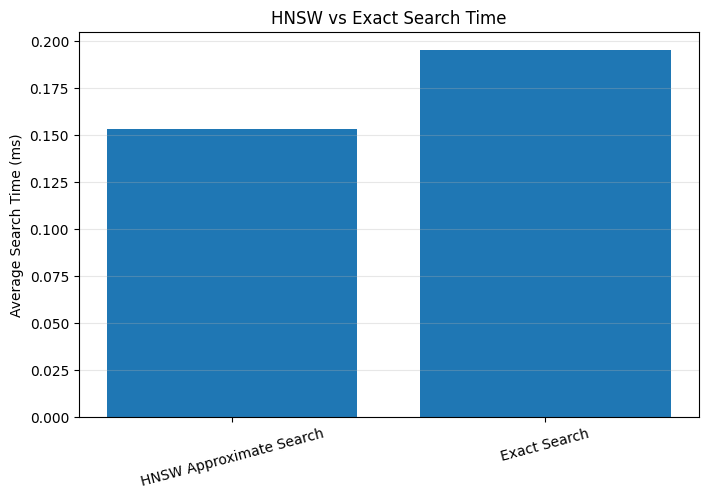

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    performance["Method"],
    performance["Average Search Time (ms)"]
)

plt.ylabel("Average Search Time (ms)")
plt.title("HNSW vs Exact Search Time")

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## Step 17: Visualize Recall@5

The distribution of Recall@5 across the tested queries is visualized below.

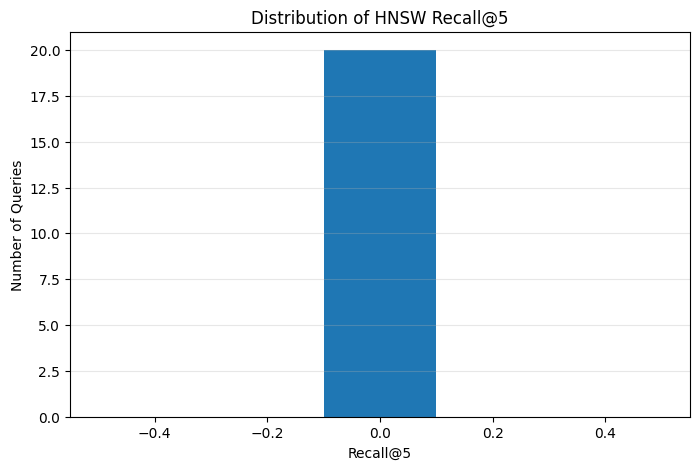

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    recalls,
    bins=5
)

plt.xlabel("Recall@5")
plt.ylabel("Number of Queries")

plt.title("Distribution of HNSW Recall@5")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## Step 18: Final Results

The HNSW implementation demonstrates:

- High-dimensional vector indexing
- Hierarchical graph construction
- Neighbor selection
- Greedy graph navigation
- Approximate nearest-neighbor search
- Exact nearest-neighbor comparison
- Recall@5 evaluation
- Search-time measurement

In [20]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Vectors",
        "Vector Dimension",
        "Number of Layers",
        "Maximum Neighbors",
        "Average Recall@5",
        "Average HNSW Search Time (ms)",
        "Average Exact Search Time (ms)"
    ],
    "Value": [
        num_vectors,
        vector_dimension,
        hnsw.max_layers,
        hnsw.max_neighbors,
        round(np.mean(recalls), 4),
        round(np.mean(hnsw_times), 4),
        round(np.mean(exact_times), 4)
    ]
})

summary

,Metric,Value
0,Number of Vectors,1000.0000
1,Vector Dimension,32.0000
2,Number of Layers,4.0000
3,Maximum Neighbors,8.0000
4,Average Recall@5,0.0000
5,Average HNSW Search Time (ms),0.1531
6,Average Exact Search Time (ms),0.1951


# Conclusion

A simplified Hierarchical Navigable Small World (HNSW) vector index was implemented from scratch using NumPy.

The index organizes vectors into multiple graph layers and uses greedy navigation to locate approximate nearest neighbors efficiently.

The implementation was evaluated against exact nearest-neighbor search using Recall@5 and search latency.

The results demonstrate the basic principle of HNSW-based approximate nearest-neighbor search and its usefulness for efficient similarity search in high-dimensional vector spaces.